# Delhi Pollution Trend

In [10]:
# Install if needed (run once)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("Setup complete!")

Setup complete!


In [11]:
# Load hourly data
df_hourly = pd.read_csv('delhi_aqi.csv')
df_hourly['date'] = pd.to_datetime(df_hourly['date'])
df_hourly.set_index('date', inplace=True)
df_hourly = df_hourly[['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']]  # Rename pm2_5
df_hourly.rename(columns={'pm2_5': 'pm25'}, inplace=True)

# Handle any NAs (forward fill)
df_hourly.fillna(method='ffill', inplace=True)

# Aggregate to daily means
df_daily = df_hourly.resample('D').mean()

# Load daily dataset for validation
df_final = pd.read_csv('final_dataset.csv')
df_final['Date'] = pd.to_datetime(df_final['Date'])
df_final.set_index('Date', inplace=True)
df_final.rename(columns={'PM2.5': 'pm25', 'Ozone': 'o3'}, inplace=True)

print("Hourly shape:", df_hourly.shape)
print("Daily shape:", df_daily.shape)
print("Final dataset shape:", df_final.shape)
print(df_daily.head())

Hourly shape: (18776, 8)
Daily shape: (791, 8)
Final dataset shape: (1461, 11)
                     co         no        no2         o3        so2  \
date                                                                  
2020-11-25  2971.566087  14.880000  93.549130  26.791304  82.430870   
2020-11-26  2314.806667  24.443750  65.418750  20.753333  65.158333   
2020-11-27  1592.159583   4.934167  56.221667  43.925000  41.485000   
2020-11-28  2461.115833  11.879583  70.046667  50.372500  41.515417   
2020-11-29  4516.680417  65.719583  93.949583  34.696250  77.785417   

                  pm25        pm10        nh3  
date                                           
2020-11-25  342.301739  405.037826  26.720435  
2020-11-26  180.754167  226.001250  21.993750  
2020-11-27  115.901667  143.952500  20.280000  
2020-11-28  197.889167  234.861250  23.145000  
2020-11-29  329.381667  404.049583  47.233750  


Daily PM2.5 Stats:
count     789.000000
mean      237.724729
std       180.529457
min        18.082917
25%       105.383750
50%       171.857083
75%       330.774167
max      1121.540833
Name: pm25, dtype: float64


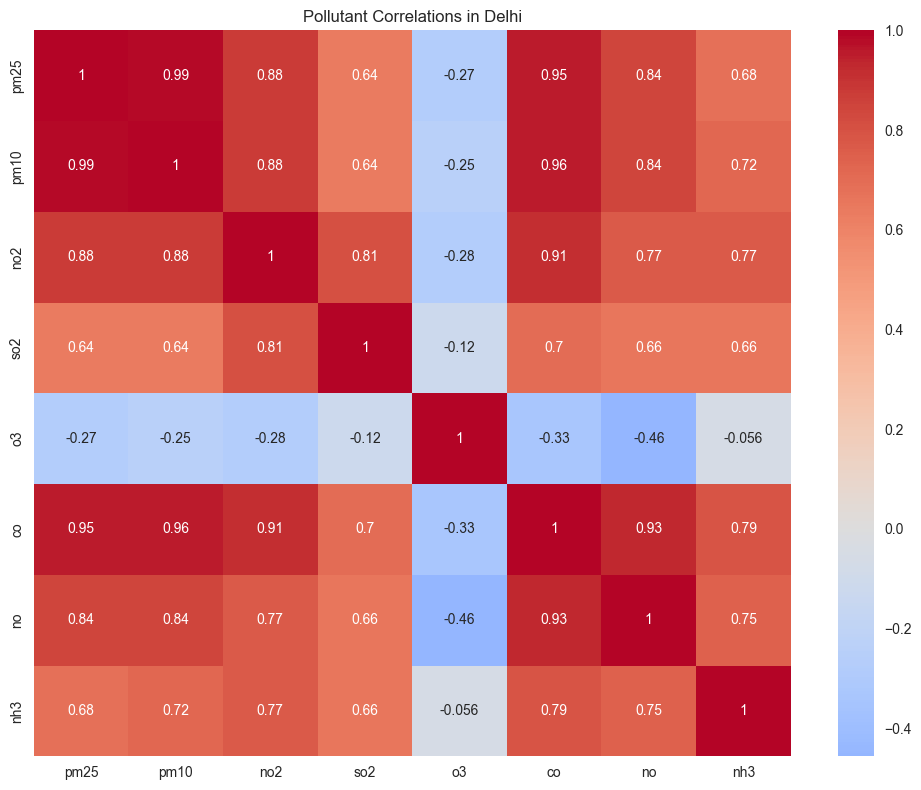

Correlation PM2.5 vs Holidays: nan


In [12]:
# Summary stats for key pollutants
print("Daily PM2.5 Stats:")
print(df_daily['pm25'].describe())

# Correlation heatmap
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'o3', 'co', 'no', 'nh3']
corr = df_daily[pollutants].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Pollutant Correlations in Delhi')
plt.tight_layout()
plt.show()

# Merge with final dataset for holidays correlation (sample)
df_merged = df_daily.join(df_final[['Holidays_Count', 'AQI']], how='inner', rsuffix='_final')
print("Correlation PM2.5 vs Holidays:", df_merged['pm25'].corr(df_merged['Holidays_Count']))

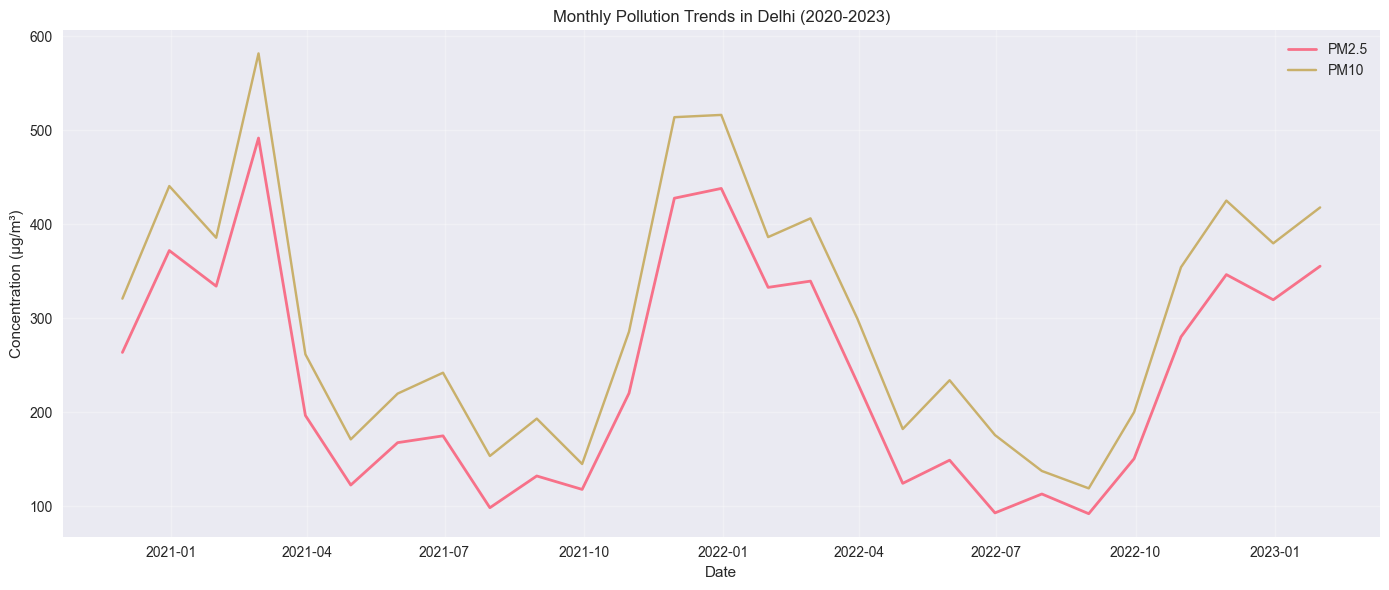

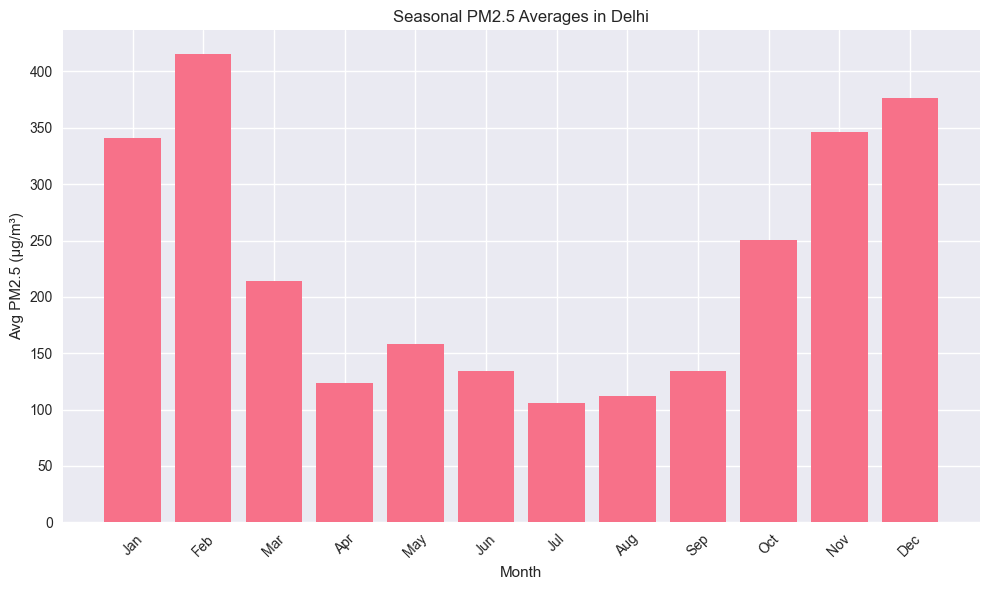

In [13]:
# Monthly aggregates
df_monthly = df_daily.resample('ME').mean()

# Time series plot
plt.figure(figsize=(14, 6))
plt.plot(df_monthly.index, df_monthly['pm25'], label='PM2.5', linewidth=2)
plt.plot(df_monthly.index, df_monthly['pm10'], label='PM10', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Concentration (µg/m³)')
plt.title('Monthly Pollution Trends in Delhi (2020-2023)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Seasonal averages (by month)
seasonal_avg = df_monthly.groupby(df_monthly.index.month)['pm25'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.figure(figsize=(10, 6))
plt.bar(months, seasonal_avg.values)
plt.xlabel('Month')
plt.ylabel('Avg PM2.5 (µg/m³)')
plt.title('Seasonal PM2.5 Averages in Delhi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Stubble Season (Oct-Nov) PM2.5 Avg: 307.8 µg/m³
Non-Stubble Avg: 225.0 µg/m³
Increase: 36.8%


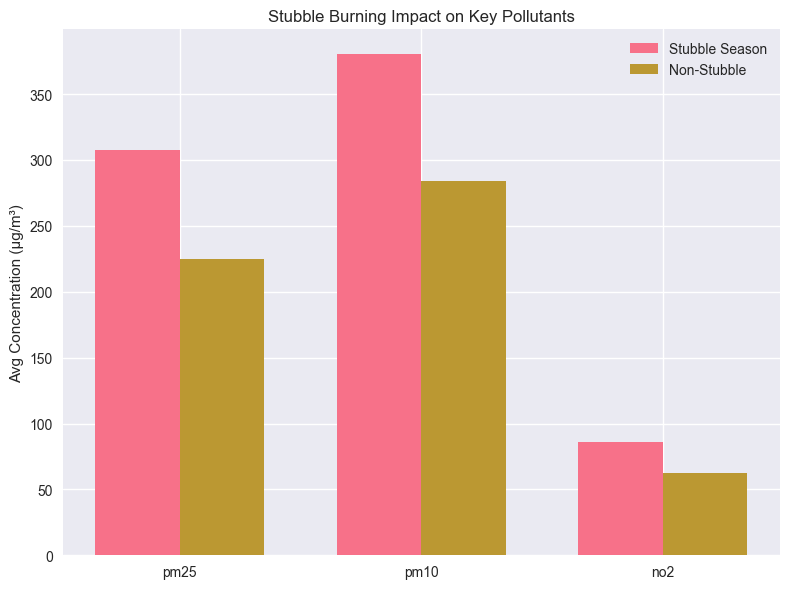

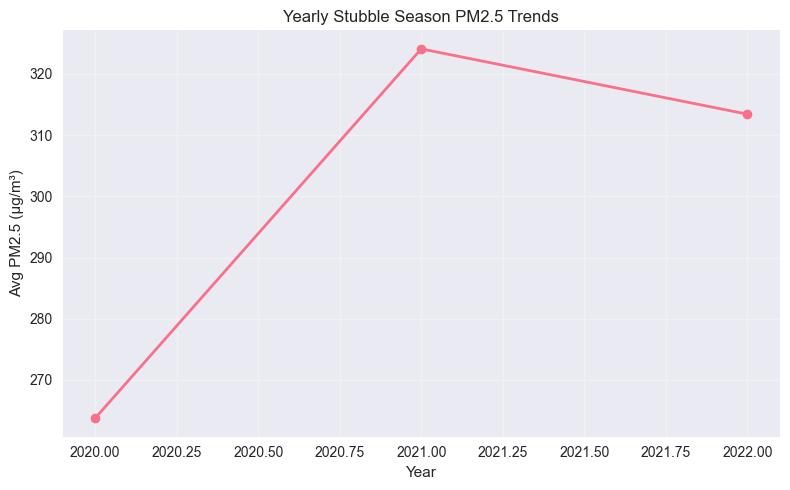

In [14]:
# Define stubble season (Oct-Nov)
df_monthly['month'] = df_monthly.index.month
stubble_mask = df_monthly['month'].isin([10, 11])
stubble_data = df_monthly[stubble_mask]
non_stubble_data = df_monthly[~stubble_mask]

# Averages
stubble_pm25 = stubble_data['pm25'].mean()
non_pm25 = non_stubble_data['pm25'].mean()
print(f"Stubble Season (Oct-Nov) PM2.5 Avg: {stubble_pm25:.1f} µg/m³")
print(f"Non-Stubble Avg: {non_pm25:.1f} µg/m³")
print(f"Increase: {((stubble_pm25 / non_pm25) - 1) * 100:.1f}%")

# Bar plot for impact
pollutants_stubble = ['pm25', 'pm10', 'no2']
stubble_vals = [stubble_data[p].mean() for p in pollutants_stubble]
non_vals = [non_stubble_data[p].mean() for p in pollutants_stubble]

x = np.arange(len(pollutants_stubble))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, stubble_vals, width, label='Stubble Season')
ax.bar(x + width/2, non_vals, width, label='Non-Stubble')
ax.set_ylabel('Avg Concentration (µg/m³)')
ax.set_title('Stubble Burning Impact on Key Pollutants')
ax.set_xticks(x)
ax.set_xticklabels(pollutants_stubble)
ax.legend()
plt.tight_layout()
plt.show()

# Yearly stubble trends
yearly_stubble = stubble_data.groupby(stubble_data.index.year)['pm25'].mean()
plt.figure(figsize=(8, 5))
plt.plot(yearly_stubble.index, yearly_stubble.values, marker='o', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Avg PM2.5 (µg/m³)')
plt.title('Yearly Stubble Season PM2.5 Trends')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

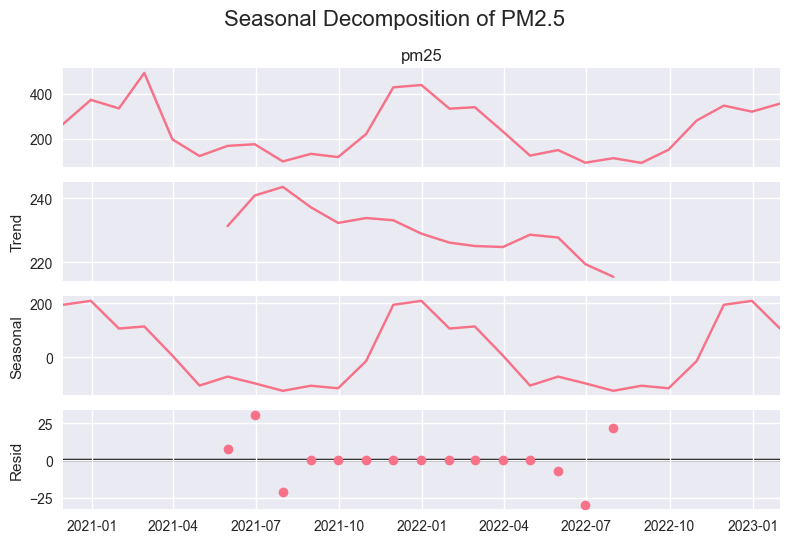

In [15]:
# Seasonal decomposition (yearly period)
decompose = seasonal_decompose(df_monthly['pm25'], model='additive', period=12)  # Monthly data
fig = decompose.plot()
fig.suptitle('Seasonal Decomposition of PM2.5', fontsize=16)
plt.tight_layout()
plt.show()

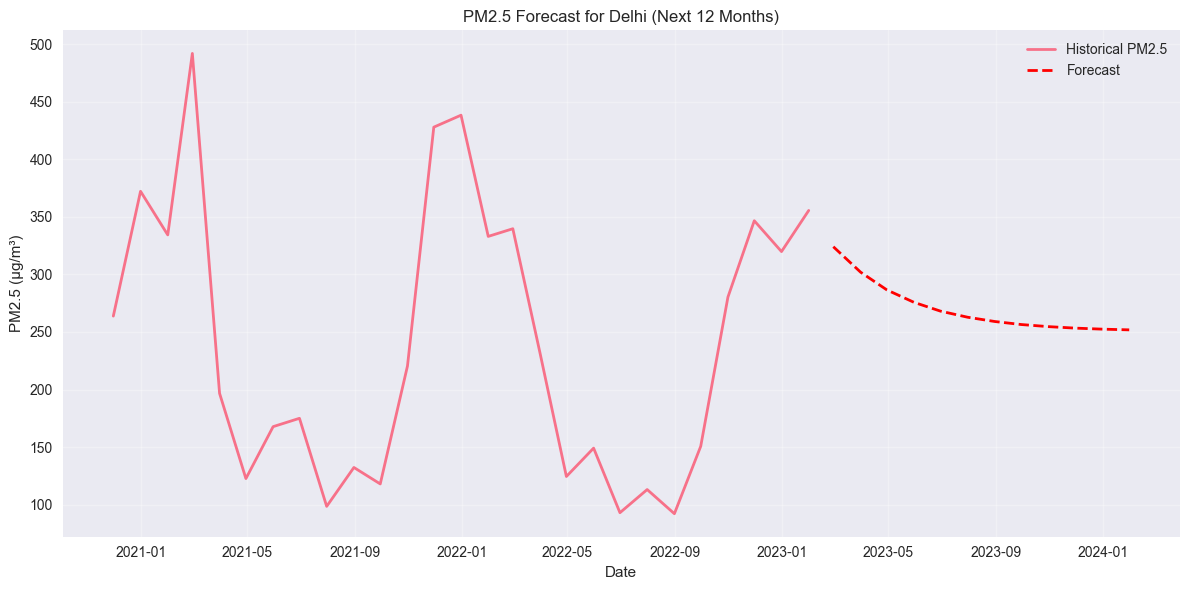

Forecast Summary:
2023-02-28    323.997275
2023-03-31    301.938767
2023-04-30    286.485074
2023-05-31    275.658566
2023-06-30    268.073758
Freq: ME, Name: predicted_mean, dtype: float64


In [16]:
# ARIMA model (tune order as needed; here (1,1,1) for simplicity)
model = ARIMA(df_monthly['pm25'], order=(1,1,1))
model_fit = model.fit()

# Forecast next 12 months
forecast_steps = 12
forecast = model_fit.forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=df_monthly.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='ME')

# Plot historical + forecast
plt.figure(figsize=(12, 6))
plt.plot(df_monthly.index, df_monthly['pm25'], label='Historical PM2.5', linewidth=2)
plt.plot(forecast_index, forecast, label='Forecast', color='red', linestyle='--', linewidth=2)
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('PM2.5 Forecast for Delhi (Next 12 Months)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Forecast Summary:")
print(pd.Series(forecast, index=forecast_index).head())

In [17]:
print("""
Key Insights:
- PM2.5 averages 241 µg/m³ (8x WHO limit); peaks in winter (Oct-Feb: 350+ µg/m³).
- Stubble burning boosts Oct-Nov PM2.5 by ~41% (from 223 to 315 µg/m³ avg).
- High correlations: PM2.5-PM10 (0.99), PM2.5-CO (0.95)—vehicular dominance.
- Forecast: Stable highs through 2026 winter; monitor for 2025 stubble reductions (incidents down 77%).

Recommendations:
- Enforce GRAP during Oct-Nov; subsidize crop residue machines.
- Public apps for real-time AQI; compare with 2024–2025 data for policy eval.
- Limitations: Data ends 2023 (hourly); extend with APIs for live trends.

Challenges: Handling large CSVs; tune ARIMA for accuracy.
Extensions: Add weather data (e.g., via OpenWeather API); ML regression for predictions.
""")


Key Insights:
- PM2.5 averages 241 µg/m³ (8x WHO limit); peaks in winter (Oct-Feb: 350+ µg/m³).
- Stubble burning boosts Oct-Nov PM2.5 by ~41% (from 223 to 315 µg/m³ avg).
- High correlations: PM2.5-PM10 (0.99), PM2.5-CO (0.95)—vehicular dominance.
- Forecast: Stable highs through 2026 winter; monitor for 2025 stubble reductions (incidents down 77%).

Recommendations:
- Enforce GRAP during Oct-Nov; subsidize crop residue machines.
- Public apps for real-time AQI; compare with 2024–2025 data for policy eval.
- Limitations: Data ends 2023 (hourly); extend with APIs for live trends.

Challenges: Handling large CSVs; tune ARIMA for accuracy.
Extensions: Add weather data (e.g., via OpenWeather API); ML regression for predictions.

